# AstroKit Extinction Correction Demo

This notebook shows how to use `astrokit.extinction.ExtinctionCorrection` to estimate Galactic foreground extinction from the SFD dust map and the Fitzpatrick & Massa (2007, FM07) Milky Way extinction curve.

The default setup uses the common astronomical convention `R_V = 3.1` and applies the Schlafly & Finkbeiner (2011) SFD recalibration factor `0.86`.

## 1. Imports

The first cell makes the local source tree importable when this notebook is launched from `demo/notebooks`. If AstroKit is already installed in your environment, this cell is still safe to run.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Make the local source tree importable when running this notebook from demo/notebooks.
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "astrokit" / "__init__.py").exists():
        sys.path.insert(0, str(parent))
        break

from astrokit.extinction import ExtinctionCorrection

## 2. Create the extinction corrector

`ExtinctionCorrection` loads the SFD map from AstroKit's dataset directory. If the map is not present, it will try to download it automatically.

In [2]:
extcorr = ExtinctionCorrection()

print(f"SFD scaling factor: {extcorr.scaling}")
print(f"R_V: {extcorr.Rv}")
print(f"SFD map directory: {extcorr.dir_sfdmap}")

SFD scaling factor: 0.86
R_V: 3.1
SFD map directory: /Users/rui/Packages/astrokit/astrokit/datasets/data/dustmaps/sfddata-master


## 3. Query SFD E(B-V)

The coordinates are ICRS RA and Dec in degrees. Scalars and arrays are both accepted.

In [3]:
# Example sky positions: two COSMOS-like coordinates.
ra = np.array([150.116321, 149.998901])
dec = np.array([2.205830, 2.000100])

ebv = extcorr.cal_ebv(ra, dec)

for i, (r, d, e) in enumerate(zip(ra, dec, ebv), start=1):
    print(f"source {i}: RA={r:.6f} deg, Dec={d:.6f} deg, E(B-V)={e:.5f} mag")

source 1: RA=150.116321 deg, Dec=2.205830 deg, E(B-V)=0.01577 mag
source 2: RA=149.998901 deg, Dec=2.000100 deg, E(B-V)=0.01623 mag


## 4. Monochromatic extinction coefficients

`cal_extinction_coeff` returns `A_lambda / E(B-V)` at the input wavelengths in Angstrom. The calculation uses FM07 by default.

In [4]:
filter_waves = np.array([4770.0, 6231.0, 7625.0, 9134.0])
filter_names = np.array(["g", "r", "i", "z"])

coeff = extcorr.cal_extinction_coeff(filter_waves)

print("Filter  Wavelength[A]  A_lambda/E(B-V)")
for name, wave, c in zip(filter_names, filter_waves, coeff):
    print(f"{name:>6s}  {wave:12.1f}  {c:15.4f}")

Filter  Wavelength[A]  A_lambda/E(B-V)
     g        4770.0           3.7269
     r        6231.0           2.5981
     i        7625.0           1.8486
     z        9134.0           1.3291


## 5. Extinction at each coordinate

`cal_extinction` multiplies the SFD `E(B-V)` values by the FM07 coefficients. For historical compatibility, the return value is a list with one array per wavelength.

In [5]:
A_lambda_list = extcorr.cal_extinction(ra, dec, filter_waves)
A_lambda = np.column_stack(A_lambda_list)

print("A_lambda [mag]")
print("source  " + "  ".join([f"{name:>8s}" for name in filter_names]))
for idx, row in enumerate(A_lambda, start=1):
    values = "  ".join([f"{value:8.4f}" for value in row])
    print(f"{idx:>6d}  {values}")

A_lambda [mag]
source         g         r         i         z
     1    0.0588    0.0410    0.0292    0.0210
     2    0.0605    0.0422    0.0300    0.0216


## 6. Correct observed magnitudes

Foreground extinction makes observed magnitudes fainter. Corrected magnitudes are therefore

`m_corrected = m_observed - A_lambda`.

In [6]:
observed_mag = np.array([
    [24.11, 23.64, 23.21, 22.95],
    [25.02, 24.33, 23.80, 23.42],
])

corrected_mag = observed_mag - A_lambda

print("Corrected magnitudes")
print("source  " + "  ".join([f"{name:>8s}" for name in filter_names]))
for idx, row in enumerate(corrected_mag, start=1):
    values = "  ".join([f"{value:8.3f}" for value in row])
    print(f"{idx:>6d}  {values}")

Corrected magnitudes
source         g         r         i         z
     1    24.051    23.599    23.181    22.929
     2    24.960    24.288    23.770    23.398


## 7. Broadband extinction coefficient

For a full filter response curve, use `cal_bandpass_coeff(waves, response)`. The integration assumes an AB-system source with flat `f_nu`, so the effective weights are `response / wavelength`.

This example uses a synthetic Gaussian filter profile.

In [7]:
waves = np.linspace(4500.0, 7500.0, 600)
response = np.exp(-0.5 * ((waves - 6100.0) / 450.0) ** 2)

A_band_over_ebv = extcorr.cal_bandpass_coeff(waves, response)
A_band = ebv * A_band_over_ebv

print(f"Synthetic band A_band/E(B-V): {A_band_over_ebv:.4f}")
for i, value in enumerate(A_band, start=1):
    print(f"source {i}: A_band={value:.4f} mag")

Synthetic band A_band/E(B-V): 2.6839
source 1: A_band=0.0423 mag
source 2: A_band=0.0436 mag


## 8. Plot the FM07 curve and the example bandpass

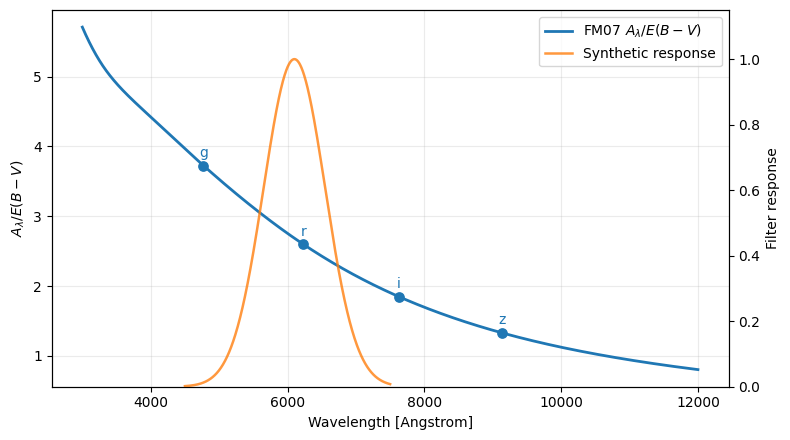

In [8]:
curve_waves = np.linspace(3000.0, 12000.0, 900)
curve_coeff = extcorr.cal_extinction_coeff(curve_waves)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(curve_waves, curve_coeff, color="tab:blue", lw=2, label=r"FM07 $A_\lambda / E(B-V)$")
ax1.scatter(filter_waves, coeff, color="tab:blue", s=45, zorder=3)
for name, wave, c in zip(filter_names, filter_waves, coeff):
    ax1.text(wave, c + 0.08, name, ha="center", va="bottom", color="tab:blue")

ax1.set_xlabel("Wavelength [Angstrom]")
ax1.set_ylabel(r"$A_\lambda / E(B-V)$")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(waves, response, color="tab:orange", lw=1.8, alpha=0.8, label="Synthetic response")
ax2.set_ylabel("Filter response")
ax2.set_ylim(0, 1.15)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")
fig.tight_layout()

## 9. Multiple broadband filters

`cal_bandpass_extinction` accepts a dictionary of filter response curves and returns one extinction array per filter.

In [9]:
blue_waves = np.linspace(3600.0, 5600.0, 400)
red_waves = np.linspace(6500.0, 9500.0, 400)

bandpasses = {
    "blue": (blue_waves, np.exp(-0.5 * ((blue_waves - 4700.0) / 330.0) ** 2)),
    "red": (red_waves, np.exp(-0.5 * ((red_waves - 7800.0) / 520.0) ** 2)),
}

band_ext = extcorr.cal_bandpass_extinction(ra, dec, bandpasses)

for name, values in band_ext.items():
    formatted = ", ".join([f"{value:.4f}" for value in values])
    print(f"{name}: [{formatted}] mag")

blue: [0.0596, 0.0613] mag
red: [0.0281, 0.0289] mag


## Notes

- Input wavelengths are in Angstrom.
- Coordinates are ICRS RA/Dec in degrees.
- `cal_extinction` returns a list of arrays to preserve the historical AstroKit API.
- `cal_bandpass_extinction` returns a dictionary keyed by filter name.
- For most Milky Way foreground work, the default `R_V = 3.1` FM07 curve is the recommended choice.